In [ ]:
#SPY Daily Returns and Standard Deviation

In [ ]:
#TLT Daily Returns and Standard Deviation

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
df2 = yf.download("TLT", start="2015-01-01", end="2025-03-24", interval="1d")

clipped2 = df2.drop(['Open', 'High', 'Low', 'Volume'], axis=1)

print(clipped2.head())

closing_prices1 = df2["Close"].values
closing_prices2 = closing_prices1.flatten()
print(closing_prices2)

daily_returns1 = np.diff(closing_prices2) / closing_prices2[:-1]
print(daily_returns1)


daily_returns1= daily_returns1  * 100
returns_df2 = pd. DataFrame({"Daily Return (%)": daily_returns1.round(2)}, index = df2.index[1:])

returns_df2["30 Day Standard Deviation (%)"] = returns_df2["Daily Return (%)"].rolling(window=30).std()

print(returns_df2)


[*********************100%***********************]  1 of 1 completed

Price            Close
Ticker             TLT
Date                  
2015-01-02   97.964386
2015-01-05   99.503311
2015-01-06  101.296059
2015-01-07  101.096016
2015-01-08   99.757179
[ 97.96438599  99.50331116 101.29605865 ...  90.85346222  90.91324615
  90.37518311]
[ 0.01570903  0.01801696 -0.00197483 ...  0.00518133  0.00065803
 -0.00591842]
            Daily Return (%)  30 Day Standard Deviation (%)
Date                                                       
2015-01-05              1.57                            NaN
2015-01-06              1.80                            NaN
2015-01-07             -0.20                            NaN
2015-01-08             -1.32                            NaN
2015-01-09              1.10                            NaN
...                      ...                            ...
2025-03-17              0.50                       0.890718
2025-03-18              0.10                       0.881485
2025-03-19              0.52                       0

[*********************100%***********************]  2 of 2 completed



--- Risk Metrics ---

SPY:
Annualized Return: 14.11%
Annualized Volatility: 17.58%
Sharpe Ratio (RF=4.00%): 0.5748

TLT:
Annualized Return: 0.37%
Annualized Volatility: 15.26%
Sharpe Ratio (RF=4.00%): -0.2377


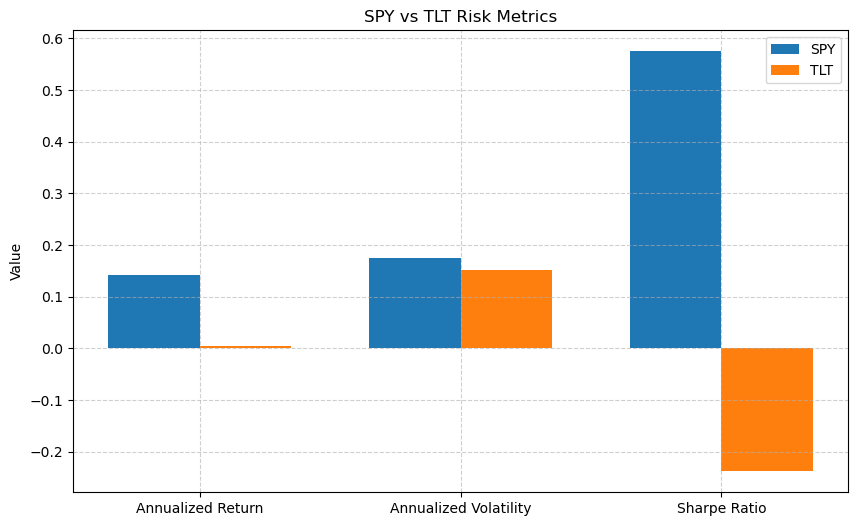

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Set risk-free rate (e.g., 4%)
risk_free_rate = 0.04  # 4% per year

# Define tickers and time range
tickers = ['SPY', 'TLT']
start_date = "2015-01-01"
end_date = "2025-03-24"

# Download data
df = yf.download(tickers, start=start_date, end=end_date, interval="1d")['Close']

# Store results
results = {}

# Loop through each asset
for ticker in tickers:
    closing_prices = df[ticker].dropna().values.flatten()
    
    # Daily returns
    daily_returns = np.diff(closing_prices) / closing_prices[:-1]
    
    # Daily stats
    mean_daily_return = np.mean(daily_returns)
    std_daily_return = np.std(daily_returns)
    
    # Annualize
    annualized_return = (1 + mean_daily_return)**252 - 1
    annualized_volatility = std_daily_return * np.sqrt(252)
    
    # Sharpe ratio
    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility
    
    # Store results
    results[ticker] = {
        'Annualized Return': annualized_return,
        'Annualized Volatility': annualized_volatility,
        'Sharpe Ratio': sharpe_ratio
    }

# Display results
print("\n--- Risk Metrics ---")
for ticker in tickers:
    print(f"\n{ticker}:")
    print(f"Annualized Return: {results[ticker]['Annualized Return']:.2%}")
    print(f"Annualized Volatility: {results[ticker]['Annualized Volatility']:.2%}")
    print(f"Sharpe Ratio (RF={risk_free_rate:.2%}): {results[ticker]['Sharpe Ratio']:.4f}")

# Optional: Plot comparison
labels = ['Annualized Return', 'Annualized Volatility', 'Sharpe Ratio']
x = np.arange(len(labels))
width = 0.35

spy_vals = [results['SPY'][label] for label in labels]
tlt_vals = [results['TLT'][label] for label in labels]

plt.figure(figsize=(10,6))
plt.bar(x - width/2, spy_vals, width, label='SPY')
plt.bar(x + width/2, tlt_vals, width, label='TLT')
plt.xticks(x, labels)
plt.ylabel("Value")
plt.title("SPY vs TLT Risk Metrics")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [23]:
# Set portfolio weights
weights = np.array([0.6, 0.4])  # 60% SPY, 40% TLT
risk_free_rate = 0.04  # 4%

# Re-fetch clean closing prices (in case earlier df has missing data misalignment)
df = yf.download(['SPY', 'TLT'], start="2015-01-01", end="2025-03-24", interval="1d")['Close'].dropna()

# Calculate daily returns for both assets
daily_returns = df.pct_change().dropna()

# Calculate portfolio daily return
portfolio_daily_returns = daily_returns.dot(weights)

# Calculate stats
mean_daily_return = portfolio_daily_returns.mean()
std_daily_return = portfolio_daily_returns.std()

# Annualize
annualized_return = (1 + mean_daily_return)**252 - 1
annualized_volatility = std_daily_return * np.sqrt(252)
sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility

# Print results
print("\n--- 60/40 SPY-TLT Portfolio Metrics ---")
print(f"Annualized Return: {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")
print(f"Sharpe Ratio (RF={risk_free_rate:.2%}): {sharpe_ratio:.4f}")


[*********************100%***********************]  2 of 2 completed


--- 60/40 SPY-TLT Portfolio Metrics ---
Annualized Return: 8.40%
Annualized Volatility: 11.05%
Sharpe Ratio (RF=4.00%): 0.3985


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Set risk-free rate and weights
risk_free_rate = 0.04  # 4% annual
weights = np.array([0.4, 0.6])  # 40% AAPL, 60% MSFT

# Download data from 2015 to 2025
tickers = ['AAPL', 'MSFT']
df = yf.download(tickers, start="2015-01-01", end="2025-03-24", interval="1d")['Close'].dropna()

# Calculate daily returns
daily_returns = df.pct_change().dropna()

# Portfolio daily returns
portfolio_daily_returns = daily_returns.dot(weights)

# Daily stats
mean_daily_return = portfolio_daily_returns.mean()
std_daily_return = portfolio_daily_returns.std()

# Annualize
annualized_return = (1 + mean_daily_return)**252 - 1
annualized_volatility = std_daily_return * np.sqrt(252)
sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility

# Print results
print("\n--- 40/60 AAPL-MSFT Portfolio Metrics (2015–2025) ---")
print(f"Annualized Return: {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")
print(f"Sharpe Ratio (RF={risk_free_rate:.2%}): {sharpe_ratio:.4f}")


[*********************100%***********************]  2 of 2 completed


--- 40/60 AAPL-MSFT Portfolio Metrics (2015–2025) ---
Annualized Return: 29.49%
Annualized Volatility: 25.41%
Sharpe Ratio (RF=4.00%): 1.0033
